In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

#import seaborn as sns
import gc
import psutil
import os, random
import posixpath

from pyhdas.frequency import spectrogram, add_db, energy
from pyhdas.aggregate import quantile
from pyhdas.aragon import concat_raw_data, aragon_select_files

from datetime import timedelta

In [2]:
import warnings

# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)


In [4]:
# load the data
import os
DATA_DIR=os.environ['FLUVES_BASE_DATA_DIR']
DATA_DIR

'/Users/gjwdijk/Texcel Dropbox/Gert-Jan Van Dijk/Thunderbyte Team Folder/Fluves'

In [7]:
# load the event table 
events = pd.read_csv("../data/01_raw/events_table.csv", parse_dates=["start", "end"])
events

,start,end,poi,ground,label_anon
0,2021-02-25 07:03:50,2021-02-25 07:06:22,"4240,4250",asphalt,label_0
1,2021-02-25 07:06:06,2021-02-25 07:08:00,"4220, 4230, 4240, 4250 ,4260",asphalt,label_1
2,2021-02-25 06:54:39,2021-02-25 07:06:06,"4220, 4230, 4240, 4250 ,4260",asphalt,label_2
3,2021-02-25 07:06:35,2021-02-25 07:07:21,"4240,4250",asphalt,label_0
4,2021-02-25 07:07:35,2021-02-25 07:12:30,"4240,4250",asphalt,label_0
...,...,...,...,...,...
619,2021-02-26 13:24:50,2021-02-26 13:27:20,"4210, 4250, 4260",pipe,label_11
620,2021-02-26 13:34:04,2021-02-26 13:34:25,"4210, 4250, 4260",pipe,label_11
621,2021-02-26 13:37:40,2021-02-26 13:38:18,"4210, 4250, 4260",pipe,label_11
622,2021-02-26 13:41:18,2021-02-26 13:42:32,"4210, 4250, 4260",NaN,label_11


In [8]:
def sound_level():
    # loop through event table 
    for _, event in events.iterrows():
        # load the event data
        start, end, poi, label = event["start"], event["end"], event["poi"], event["label_anon"]
        # select the locations 50m here, 50m there 
        poi = np.arange(4150, 4350, 10)
        # if the duration of the event is more than 2 minutes, print the event_label, date and start and end time, and move on to the next row
        event_duration = (end - start).total_seconds()
        if event_duration > 120 or event_duration <= 1:
            continue
    
        # load the strain data based on the start and the end of the event
        start = pd.Timestamp(start)
        end = pd.Timestamp(end)
        start = start.tz_localize("UTC")
        end = end.tz_localize("UTC")
        day = start.day

        dir_data = Path(fr"{DATA_DIR}/{day}")
        file_list = list(aragon_select_files(dir_data, start, end, extension="bin"))
        if not file_list:
            print(f"The list is empty: {start}, {end}, {label}")
            continue

        ds_raw = concat_raw_data(file_list)
        start = start.tz_localize(None)
        end = end.tz_localize(None)

        # sound level 
        ds_raw = ds_raw.sel(time=slice(start, end), position=poi)
        ds_spect = spectrogram(ds_raw, variable='strain') 
        ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
        ds_soundlevel = add_db(ds_soundlevel)   

        # Plot soundlevel over time and all positions
        fig,ax = plt.subplots(figsize=(15,6))
        ds_soundlevel.Pxx_dB.plot(x="position", y="time", ax=ax, vmax = 40, cmap="magma")
        ax.set_title(f"soundlevel [dB] over all frequencies")

        # save the plot
        output_folder = Path(f"soundlevel_plots/{label}")
        output_folder.mkdir(parents=True, exist_ok=True)
  
        plot_filename = f"{start.strftime('%Y-%m-%d_%H:%M:%S')}_{end.strftime('%H:%M:%S')}_soundlevel.png"
        plt.savefig(output_folder / plot_filename, bbox_inches='tight')

        plt.close(fig)
        
        print(f"Done with {start}, {end}, {label}")
        del ds_raw, ds_spect, ds_soundlevel
        gc.collect()

Done with 2021-02-25 07:06:06, 2021-02-25 07:08:00, label_1
Done with 2021-02-25 07:06:35, 2021-02-25 07:07:21, label_0
Done with 2021-02-25 07:09:51, 2021-02-25 07:10:10, label_3
Done with 2021-02-25 07:10:10, 2021-02-25 07:11:33, label_3
Done with 2021-02-25 07:14:33, 2021-02-25 07:14:43, label_1
Done with 2021-02-25 07:14:43, 2021-02-25 07:15:08, label_4
Done with 2021-02-25 07:15:08, 2021-02-25 07:15:25, label_1
Done with 2021-02-25 07:15:25, 2021-02-25 07:16:16, label_4
Done with 2021-02-25 07:16:16, 2021-02-25 07:16:37, label_2
Done with 2021-02-25 07:16:37, 2021-02-25 07:17:05, label_4
Done with 2021-02-25 07:17:05, 2021-02-25 07:18:06, label_2
Done with 2021-02-25 07:18:08, 2021-02-25 07:19:04, label_4
Done with 2021-02-25 07:22:20, 2021-02-25 07:23:51, label_0
Done with 2021-02-25 07:44:52, 2021-02-25 07:45:00, label_5
Done with 2021-02-25 07:45:07, 2021-02-25 07:45:18, label_5
Done with 2021-02-25 07:45:07, 2021-02-25 07:45:18, label_5
Done with 2021-02-25 07:45:26, 2021-02-2

ValueError: Cannot specify both x and y kwargs for line plots.

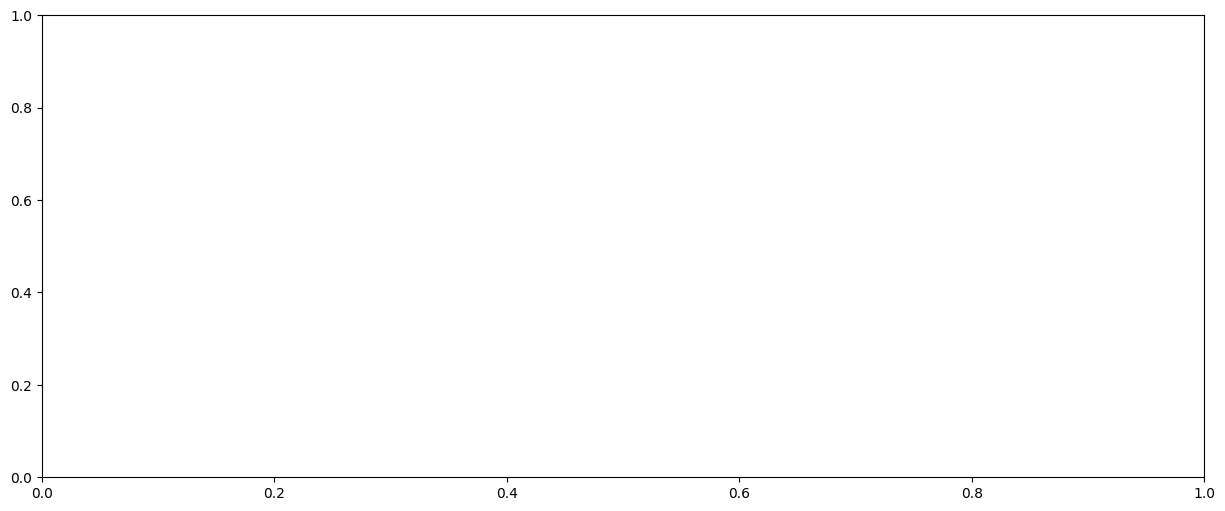

In [9]:
sound_level()

In [10]:
# select 200 random files from the directory
normal_data_dir = f"{DATA_DIR}/19"
files = random.sample(os.listdir(normal_data_dir), 100)

In [11]:
def sound_normal():
    for file in files:

        filepath = [posixpath.join(normal_data_dir, file)]

        # open file one by one
        ds_raw = concat_raw_data(filepath)

        poi = np.arange(60, 6950, 10)

        ds_raw = ds_raw.sel(position=poi)
        ds_spect = spectrogram(ds_raw, variable='strain')
        ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
        ds_soundlevel = add_db(ds_soundlevel)   

        # Plot soundlevel over time and all positions
        fig,ax = plt.subplots(figsize=(15,6))
        ds_soundlevel.Pxx_dB.plot(x="position", y="time", ax=ax, vmax = 40, cmap="magma")
        ax.set_title(f"soundlevel [dB] over all frequencies")
        
        # save in the normal data directory
        output_folder = Path(f"normal_soundlevel_plots_all_locs")
        output_folder.mkdir(parents=True, exist_ok=True)

        plot_filename = f"{file[:-4]}.png"
        plt.savefig(output_folder / plot_filename,  bbox_inches='tight')

        plt.close(fig)
        
        print(f"Done with {file}")
        del ds_raw, ds_spect, ds_soundlevel
        gc.collect()
        break

In [12]:
sound_normal()

Done with 2021_02_19_18h32m40s_HDAS_2DRawData_Strain.bin


In [13]:
def get_sound_normal():

    all_data = []

    normal_data_dir = f"{DATA_DIR}/19"

    for file in os.listdir(normal_data_dir):

        filepath = [posixpath.join(normal_data_dir, file)]

        # open file one by one
        ds_raw = concat_raw_data(filepath)
        
        # excluding the end of the pipe
        poi = np.arange(60, 6950, 10)

        ds_raw = ds_raw.sel(position=poi)
        ds_spect = spectrogram(ds_raw, variable='strain')
        ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
        ds_soundlevel = add_db(ds_soundlevel)  

        X_train = ds_soundlevel.Pxx_dB.values  # Extracting the numpy array
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)) 

        print(X_train.shape)
        if X_train.shape[1] != 59:
            continue
        
        all_data.append(X_train)
        print(f"Done with {file}")
    
    all_data_array = np.array(all_data)
    np.save('sound_levels_data.npy', all_data_array)
        

In [14]:
get_sound_normal()

(689, 59, 1)
Done with 2021_02_19_11h30m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_12h02m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_17h54m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_16h36m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_15h41m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_17h11m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_12h47m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_13h25m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_22h28m41s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_21h04m41s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_23h54m41s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_22h36m41s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_11h05m39s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done with 2021_02_19_12h59m40s_HDAS_2DRawData_Strain.bin
(689, 59, 1)
Done wi

In [ ]:
dir_data = Path(rf"{DATA_DIR}/25")
t_start = pd.Timestamp("2021-02-25 10:00:00+00")
t_end = pd.Timestamp("2021-02-25 10:05:00+00")
extension = "bin"

file_list = list(aragon_select_files(dir_data, t_start, t_end, extension=extension))

In [ ]:
event_start_end_times = [("2021-02-25 09:00:00+00", "2021-02-25 10:00:00+00"),
                         ("2021-02-25 10:00:00+00", "2021-02-25 11:00:00+00"),
                         ("2021-02-25 12:00:00+00", "2021-02-25 13:00:00+00"),
                         ("2021-02-25 13:00:00+00", "2021-02-25 14:00:00+00")
                         ]

normal_start_end_times = [("2021-02-19 09:00:00+00", "2021-02-19 10:00:00+00"),
                         ("2021-02-19 10:00:00+00", "2021-02-19 11:00:00+00"),
                         ("2021-02-19 12:00:00+00", "2021-02-19 13:00:00+00"),
                         ("2021-02-19 13:00:00+00", "2021-02-19 14:00:00+00")
                         ]

In [ ]:
def get_sound_anomaly(file_list, counter):

    all_data = []

    for filepath in file_list:

        # open file one by one
        ds_raw = concat_raw_data([filepath])
        
        # excluding the end of the pipe
        poi = np.arange(1260, 6950, 10)

        ds_raw = ds_raw.sel(position=poi)
        ds_spect = spectrogram(ds_raw, variable='strain')
        ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
        ds_soundlevel = add_db(ds_soundlevel)  

        X_train = ds_soundlevel.Pxx_dB.values  # Extracting the numpy array
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)) 

        print(X_train.shape)
        if X_train.shape[1] != 59:
            continue
        
        all_data.append(X_train)
        print(f"Done with {filepath}")
    
    all_data_array = np.array(all_data)
    np.save(f'sound_levels_anomaly_{counter}.npy', all_data_array)

In [ ]:
counter = 0
for event_times in event_start_end_times:

    event_start, event_end = pd.Timestamp(event_times[0]), pd.Timestamp(event_times[1])

    # load normal and event data for the same hour 9-10, 10-11, 12-13, 13-14
    event_dir = Path(rf"{DATA_DIR}/25")
    event_file_list = list(aragon_select_files(event_dir, event_start, event_end, extension="bin"))

    get_sound_anomaly(event_file_list, counter)
    counter = counter + 1

In [ ]:
def return_sound_level(file_list, poi):

    all_data = []

    for filepath in file_list:
        # extract sound levels for those hours 
        ds_raw = concat_raw_data([filepath])

        ds_raw = ds_raw.sel(position=poi)
        ds_spect = spectrogram(ds_raw, variable='strain')
        ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
        ds_soundlevel = add_db(ds_soundlevel) 

        X_train = ds_soundlevel.Pxx_dB.values 

        X_train = X_train.reshape((X_train.shape[1], X_train.shape[0])) 
        print(X_train.shape)

        if X_train.shape[0] != 59:
            continue
        
        all_data.append(X_train)
        print(f"Done with {filepath}")

    all_data = np.array(all_data)        
    return all_data


In [ ]:
# create tuples of end and beginning time 

for event_times, normal_times in zip(event_start_end_times, normal_start_end_times):

    event_start, event_end = pd.Timestamp(event_times[0]), pd.Timestamp(event_times[1])
    normal_start, normal_end = pd.Timestamp(normal_times[0]), pd.Timestamp(normal_times[1])

    # load normal and event data for the same hour 9-10, 10-11, 12-13, 13-14
    event_dir = Path(rf"{DATA_DIR}/25")
    normal_dir = Path(rf"{DATA_DIR}/19")
    event_file_list = list(aragon_select_files(event_dir, event_start, event_end, extension="bin"))
    normal_file_list = list(aragon_select_files(normal_dir, normal_start, normal_end, extension="bin"))

    event_sound_level = return_sound_level(event_file_list, np.arange(4200, 4300, 10))
    normal_sound_level = return_sound_level(normal_file_list, np.arange(4200, 4300, 10))

    event_percentiles = np.percentile(event_sound_level, 99, axis=1).flatten()
    normal_percentiles = np.percentile(normal_sound_level, 99, axis=1).flatten()

    plt.figure(figsize=(10, 6))
    sns.kdeplot(event_percentiles, color='red', label='Event', shade=True, alpha=0.6)
    sns.kdeplot(normal_percentiles, color='blue', label='Normal', shade=True, alpha=0.6)

    plt.ylim(0, 0.3)

    plt.title("Distribution of Event vs Normal Sound Levels", fontsize=14)
    plt.xlabel("Sound Level (dB)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend()

    # Show plot
    plt.show()


In [ ]:
for event_times in event_start_end_times:

    event_start, event_end = pd.Timestamp(event_times[0]), pd.Timestamp(event_times[1])

    # load normal and event data for the same hour 9-10, 10-11, 12-13, 13-14
    event_dir = Path(rf"{DATA_DIR}/25")
    event_file_list = list(aragon_select_files(event_dir, event_start, event_end, extension="bin"))

    roi_event_sound_level = return_sound_level(event_file_list, np.arange(4200, 4300, 10))
    other_event_sound_level = return_sound_level(event_file_list, np.arange(6200, 6300, 10))

    event_percentiles = np.percentile(roi_event_sound_level, 99, axis=1).flatten()
    normal_percentiles = np.percentile(other_event_sound_level, 99, axis=1).flatten()

    plt.figure(figsize=(10, 6))
    sns.kdeplot(event_percentiles, color='red', label='ROI', shade=True, alpha=0.6)
    sns.kdeplot(normal_percentiles, color='blue', label='Normal Regions', shade=True, alpha=0.6)

    plt.ylim(0, 0.3)

    plt.title("Distribution of Event vs Normal Sound Levels", fontsize=14)
    plt.xlabel("Sound Level (dB)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.legend()

    # Show plot
    plt.show()


In [ ]:
def get_sound_event_day():

    all_data = []

    normal_data_dir = f"{DATA_DIR}/25"

    for file in os.listdir(normal_data_dir):

        file_timestamp = "_".join(file.split('_')[:4]) 

        filepath = [posixpath.join(normal_data_dir, file)]

        # open file one by one
        ds_raw = concat_raw_data(filepath)
        
        # excluding the end of the pipe
        poi = np.arange(1260, 6950, 10)

        ds_raw = ds_raw.sel(position=poi)
        ds_spect = spectrogram(ds_raw, variable='strain')
        ds_soundlevel = ds_spect[["Pxx"]].sum(dim="freq")
        ds_soundlevel = add_db(ds_soundlevel)  

        X_train = ds_soundlevel.Pxx_dB.values  # Extracting the numpy array
        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)) 

        if X_train.shape[1] != 59:
            print(f"{file} has shape {X_train.shape}")
            continue
    
        all_data.append((file_timestamp, X_train)) 
        print(f"Done with {file}")
    
    dtype = [('filename', 'U256'), ('data', 'O')]
    structured_array = np.array(all_data, dtype=dtype)
    
    np.save('25_event_day.npy', structured_array)

In [ ]:
get_sound_event_day()